# Run A — YOLO26n baseline on KITTI

Baseline for the backbone-replacement study (YOLO26n backbone → ZipDepth encoder). This notebook fine-tunes the
COCO-pretrained YOLO26n on KITTI 2D detection and measures everything the comparison needs: accuracy (overall, per
class, per object size), model cost (parameters, FLOPs, latency, GPU memory) and backbone/neck feature maps.

| Run | Backbone | Notebook |
|---|---|---|
| A | YOLO26n, COCO-pretrained | baseline_yolo26n_kitti.ipynb |
| B | ZipDepth encoder, depth-pretrained | zipdepth_yolo26n_kitti.ipynb |

All runs share `exp_config.yaml` and `lab_eval.py` (both written to Drive by this notebook).
**Training is skipped when a finished run already exists on Drive**; everything else is recomputed from `best.pt`.

**Outputs** (`MyDrive/lab/`): `exp_config.yaml`, `lab_eval.py`, `cache/kitti_labels.csv`,
`runs/A_yolo26n/` (weights, `results.csv`, `epoch_log.csv`, plots), `results/results_A.json`.

## 1. Setup

In [1]:
import sys, subprocess
if "google.colab" in sys.modules:
    subprocess.run([sys.executable, "-m", "pip", "-q", "install", "ultralytics>=8.4"], check=True)

In [2]:
import os, json, time, copy, random, shutil, importlib
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, torch, yaml
from PIL import Image

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    ROOT, DATA_ROOT = Path("/content/drive/MyDrive/lab"), Path("/content/datasets")
    os.chdir("/content")
else:
    ROOT, DATA_ROOT = Path("lab_drive").resolve(), Path("datasets").resolve()
ROOT.mkdir(parents=True, exist_ok=True); DATA_ROOT.mkdir(parents=True, exist_ok=True)

import ultralytics
from ultralytics import YOLO

DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"

GPU_NAME = torch.cuda.get_device_name(0) if DEVICE != "cpu" else "CPU"

SMOKE = DEVICE == "cpu"                        # CPU: pipeline check only (tiny run, 300 val images)
RUN_NAME = "A_yolo26n_smoke" if SMOKE else "A_yolo26n"
pd.set_option("display.precision", 3)
print(f"torch {torch.__version__} | ultralytics {ultralytics.__version__} | {GPU_NAME} | SMOKE={SMOKE} | run={RUN_NAME}")

Mounted at /content/drive
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
torch 2.11.0+cu128 | ultralytics 8.4.165 | Tesla T4 | SMOKE=False | run=A_yolo26n


## 2. Data

Ultralytics' YOLO-format KITTI (fixed split: 5,985 train / 1,496 val, 8 classes). All ground truth is parsed once into
a single table (`labels`) with pixel boxes, box height and size bucket, cached on Drive; later cells query this table
instead of reading label files. Size buckets use the box height in the original image (small < 25 px, the KITTI
minimum for the Moderate/Hard levels; medium 25–50 px; large ≥ 50 px).

In [3]:
KITTI_DIR = DATA_ROOT / "kitti"
if not (KITTI_DIR / "images/val").exists():
    subprocess.run(["wget", "-q", "-O", str(DATA_ROOT / "kitti.zip"),
                    "https://github.com/ultralytics/assets/releases/download/v0.0.0/kitti.zip"], check=True)
    subprocess.run(["unzip", "-q", "-o", str(DATA_ROOT / "kitti.zip"), "-d", str(KITTI_DIR)], check=True)
    (DATA_ROOT / "kitti.zip").unlink()

NAMES = {0: "car", 1: "van", 2: "truck", 3: "pedestrian", 4: "Person_sitting", 5: "cyclist", 6: "tram", 7: "misc"}
DATA_YAML = DATA_ROOT / "kitti.yaml"
_ = DATA_YAML.write_text(yaml.safe_dump({"path": str(KITTI_DIR), "train": "images/train", "val": "images/val",
                                     "names": NAMES}, sort_keys=False))

In [4]:
%%writefile lab_eval.py
"""lab_eval.py - shared evaluation utilities for runs A / B / C (YOLO26n vs ZipDepth backbone on KITTI).

Every run is evaluated with this file, unchanged, so that all numbers in the comparison table
come from identical code.
"""
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from PIL import Image
from ultralytics.utils.metrics import ap_per_class, box_iou

# 10 IoU thresholds of mAP50-95, built exactly like Ultralytics (float32) so that ">= threshold" matches bit for bit.
IOUV = torch.linspace(0.5, 0.95, 10).numpy()

# Size buckets by ground-truth box height in original image pixels (25 px = KITTI minimum height for Moderate/Hard).
SIZE_BUCKETS = {"small (<25px)": (0.0, 25.0), "medium (25-50px)": (25.0, 50.0), "large (>=50px)": (50.0, float("inf"))}


# ----------------------------------------------------------------------------- labels
def bucket_of(h):
    for name, (lo, hi) in SIZE_BUCKETS.items():
        if lo <= h < hi:
            return name
    return list(SIZE_BUCKETS)[0]


def build_label_df(kitti_dir, names, splits=("train", "val")):
    """One row per ground-truth object: split, image, image size, class, normalised and pixel box, height, bucket."""
    rows = []
    for split in splits:
        for img in sorted((Path(kitti_dir) / "images" / split).glob("*.png")):
            W, H = Image.open(img).size
            lbl = Path(kitti_dir) / "labels" / split / (img.stem + ".txt")
            if not lbl.exists() or lbl.stat().st_size == 0:
                continue
            for c, xc, yc, w, h in np.loadtxt(lbl, ndmin=2):
                rows.append((split, img.name, str(img), W, H, int(c), xc, yc, w, h))
    df = pd.DataFrame(rows, columns=["split", "image", "path", "img_w", "img_h", "cls", "xc", "yc", "w", "h"])
    df["name"] = df["cls"].map(names)
    df["x1"] = (df.xc - df.w / 2) * df.img_w
    df["y1"] = (df.yc - df.h / 2) * df.img_h
    df["x2"] = (df.xc + df.w / 2) * df.img_w
    df["y2"] = (df.yc + df.h / 2) * df.img_h
    df["h_px"] = df.y2 - df.y1
    df["bucket"] = df.h_px.map(bucket_of)
    return df


def load_label_df(kitti_dir, names, cache_path):
    """Build the label table once and cache it as CSV (e.g. on Drive)."""
    cache_path = Path(cache_path)
    if cache_path.exists():
        return pd.read_csv(cache_path)
    df = build_label_df(kitti_dir, names)
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(cache_path, index=False)
    return df


# ----------------------------------------------------------------------------- matching
def match_with_index(pred_cls, gt_cls, iou):
    """Greedy matching identical to Ultralytics DetectionValidator.match_predictions(use_scipy=False),
    but returning the matched gt index. iou: (L gt, D det). Returns (D, 10) int array, -1 = unmatched."""
    D, L = len(pred_cls), len(gt_cls)
    out = -np.ones((D, len(IOUV)), int)
    if D == 0 or L == 0:
        return out
    iou = iou * (gt_cls[:, None] == pred_cls[None, :])
    for i, t in enumerate(IOUV):
        m = np.array(np.nonzero(iou >= t)).T
        if m.shape[0]:
            if m.shape[0] > 1:
                m = m[iou[m[:, 0], m[:, 1]].argsort()[::-1]]
                m = m[np.unique(m[:, 1], return_index=True)[1]]
                m = m[np.unique(m[:, 0], return_index=True)[1]]
            out[m[:, 1], i] = m[:, 0]
    return out


def make_record(pred_boxes, pred_cls, pred_conf, gt_cls, gt_boxes):
    L, D = len(gt_boxes), len(pred_boxes)
    iou = (box_iou(torch.as_tensor(gt_boxes, dtype=torch.float32), torch.as_tensor(pred_boxes, dtype=torch.float32)).numpy()
           if L and D else np.zeros((L, D), np.float32))
    pred_cls, gt_cls = np.asarray(pred_cls, int), np.asarray(gt_cls, int)
    return dict(conf=np.asarray(pred_conf, np.float32), pcls=pred_cls,
                ph=(pred_boxes[:, 3] - pred_boxes[:, 1]) if D else np.zeros(0),
                match=match_with_index(pred_cls, gt_cls, iou),
                gcls=gt_cls, gh=(gt_boxes[:, 3] - gt_boxes[:, 1]) if L else np.zeros(0))


@torch.no_grad()
def collect_predictions(model, gt_df, imgsz=640, device=None, conf=0.001, iou=0.7, max_det=300):
    """Batch-1 prediction on every image in gt_df (same thresholds as model.val()), one record per image."""
    recs = []
    for path, g in gt_df.groupby("path", sort=True):
        r = model.predict(path, imgsz=imgsz, conf=conf, iou=iou, max_det=max_det, device=device, verbose=False)[0]
        b = r.boxes
        recs.append(make_record(b.xyxy.cpu().numpy(), b.cls.cpu().numpy().astype(int), b.conf.cpu().numpy(),
                                g.cls.values, g[["x1", "y1", "x2", "y2"]].values.astype(np.float32)))
    return recs


# ----------------------------------------------------------------------------- AP per size bucket
def _in(h, lo, hi):
    return ((h >= lo) | (lo <= 0)) & (h < hi)


def bucket_ap(recs, nc, lo=0.0, hi=float("inf")):
    """COCO-style AP restricted to gt boxes with height in [lo, hi).
    TP: matched a gt in the bucket. Ignored: matched a gt outside the bucket, or unmatched with its own height outside.
    FP: unmatched and inside the bucket. With (0, inf) this equals Ultralytics' mAP computation exactly.
    Returns ap (nc, 10) with NaN for classes without gt in the bucket, and n_gt (nc,)."""
    ap = np.full((nc, len(IOUV)), np.nan)
    n_gt = np.zeros(nc, int)
    for r in recs:
        n_gt += np.bincount(r["gcls"][_in(r["gh"], lo, hi)], minlength=nc)[:nc]
    for t in range(len(IOUV)):
        confs, pcls, tps, tcls = [], [], [], []
        for r in recs:
            m, in_gt, in_pred = r["match"][:, t], _in(r["gh"], lo, hi), _in(r["ph"], lo, hi)
            matched = m >= 0
            tp = np.zeros(len(m), bool)
            tp[matched] = in_gt[m[matched]]
            keep = ~((matched & ~tp) | (~matched & ~in_pred))
            confs.append(r["conf"][keep]); pcls.append(r["pcls"][keep]); tps.append(tp[keep]); tcls.append(r["gcls"][in_gt])
        tcls = np.concatenate(tcls)
        if len(tcls):
            res = ap_per_class(np.concatenate(tps)[:, None], np.concatenate(confs), np.concatenate(pcls), tcls)
            ap[res[6].astype(int), t] = res[5][:, 0]
    return dict(ap=ap, n_gt=n_gt)


def size_table(recs, names):
    """Rows: all + size buckets. Columns: n_gt, mAP50, mAP50-95, AP50-95 per class."""
    rows = []
    for bucket, (lo, hi) in {"all": (0.0, float("inf")), **SIZE_BUCKETS}.items():
        r = bucket_ap(recs, len(names), lo, hi)
        ok = ~np.isnan(r["ap"][:, 0])
        row = {"bucket": bucket, "n_gt": int(r["n_gt"].sum()),
               "mAP50": float(r["ap"][ok, 0].mean()) if ok.any() else np.nan,
               "mAP50-95": float(r["ap"][ok].mean()) if ok.any() else np.nan}
        row.update({names[c]: float(r["ap"][c].mean()) for c in range(len(names))})
        rows.append(row)
    return pd.DataFrame(rows).set_index("bucket")


# ----------------------------------------------------------------------------- features
def pca_rgb(fmap):
    """(C, H, W) feature map -> (H, W, 3) image of the top-3 principal components, and their explained variance."""
    C, H, W = fmap.shape
    X = fmap.reshape(C, -1).T.double()
    X = X - X.mean(0)
    U, S, _ = torch.linalg.svd(X, full_matrices=False)
    pcs = (U[:, :3] * S[:3]).numpy()
    lo, hi = np.percentile(pcs, 1, axis=0), np.percentile(pcs, 99, axis=0)
    img = np.clip((pcs - lo) / (hi - lo + 1e-12), 0, 1).reshape(H, W, 3)
    return img, float((S[:3] ** 2).sum() / (S ** 2).sum())


# ----------------------------------------------------------------------------- cost
def count_params(module):
    return sum(p.numel() for p in module.parameters())


@torch.no_grad()
def measure_latency(net, shape, device, half=False, warmup=30, iters=200):
    """Network forward time in ms (no pre/post-processing, no NMS)."""
    net = net.to(device).eval()
    x = torch.rand(*shape, device=device)
    if half:
        net, x = net.half(), x.half()
    for _ in range(warmup):
        net(x)
    times = []
    if str(device).startswith("cuda"):
        torch.cuda.synchronize()
        for _ in range(iters):
            s, e = torch.cuda.Event(enable_timing=True), torch.cuda.Event(enable_timing=True)
            s.record(); net(x); e.record(); torch.cuda.synchronize()
            times.append(s.elapsed_time(e))
    else:
        for _ in range(iters):
            t0 = time.perf_counter(); net(x); times.append((time.perf_counter() - t0) * 1000)
    if half:
        net.float()
    t = np.array(times)
    return dict(mean=float(t.mean()), median=float(np.median(t)), p90=float(np.percentile(t, 90)))


@torch.no_grad()
def peak_inference_memory(net, shape, device, half=False):
    """Peak GPU memory (MiB) of one forward pass: total and above the weights."""
    if not str(device).startswith("cuda"):
        return dict(total_mib=float("nan"), activations_mib=float("nan"))
    net = net.to(device).eval()
    x = torch.rand(*shape, device=device)
    if half:
        net, x = net.half(), x.half()
    torch.cuda.synchronize(); torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats(device)
    base = torch.cuda.memory_allocated(device)
    net(x); torch.cuda.synchronize()
    peak = torch.cuda.max_memory_allocated(device)
    if half:
        net.float()
    return dict(total_mib=peak / 2**20, activations_mib=(peak - base) / 2**20)


def save_json(obj, path):
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    Path(path).write_text(json.dumps(obj, indent=2, ensure_ascii=False, default=float))

Writing lab_eval.py


In [5]:
shutil.copy("lab_eval.py", ROOT / "lab_eval.py")
import lab_eval; importlib.reload(lab_eval)
from lab_eval import (SIZE_BUCKETS, load_label_df, collect_predictions, size_table, bucket_ap, make_record, pca_rgb,
                      count_params, measure_latency, peak_inference_memory, save_json)

labels = load_label_df(KITTI_DIR, NAMES, ROOT / "cache/kitti_labels.csv")
n_img = {s: len(list((KITTI_DIR / f"images/{s}").glob("*.png"))) for s in ("train", "val")}
assert n_img == {"train": 5985, "val": 1496}, n_img

val = labels[labels.split == "val"]
if SMOKE:                                      # 300-image val subset for the CPU pipeline check
    keep = sorted(random.Random(0).sample(sorted(val.path.unique()), 300))
    (DATA_ROOT / "kitti_smoke_val.txt").write_text("\n".join(keep) + "\n")
    RUN_DATA = DATA_ROOT / "kitti_smoke.yaml"
    RUN_DATA.write_text(yaml.safe_dump({"path": str(KITTI_DIR), "train": "images/train",
                                        "val": str(DATA_ROOT / "kitti_smoke_val.txt"), "names": NAMES}, sort_keys=False))
    val = val[val.path.isin(keep)]
else:
    RUN_DATA = DATA_YAML

summary = labels.pivot_table(index="name", columns="split", values="cls", aggfunc="size").reindex(NAMES.values())
by_size = (val.pivot_table(index="name", columns="bucket", values="cls", aggfunc="size", fill_value=0)
              .reindex(index=NAMES.values(), columns=SIZE_BUCKETS.keys(), fill_value=0))
tab = pd.concat([summary, by_size.add_prefix("val ")], axis=1)
tab.loc["total"] = tab.sum()
print(f"images: {n_img} | objects: {len(labels):,} | evaluation images: {val.path.nunique()}")
tab

images: {'train': 5985, 'val': 1496} | objects: 40,570 | evaluation images: 1496


,train,val,val small (<25px),val medium (25-50px),val large (>=50px)
name,,,,,
car,23026,5716,800,2214,2702
van,2359,555,37,239,279
truck,871,223,0,94,129
pedestrian,3566,921,15,122,784
Person_sitting,186,36,0,1,35
cyclist,1275,352,22,105,225
tram,394,117,4,41,72
misc,765,208,11,87,110
total,32442,8128,889,2903,4336


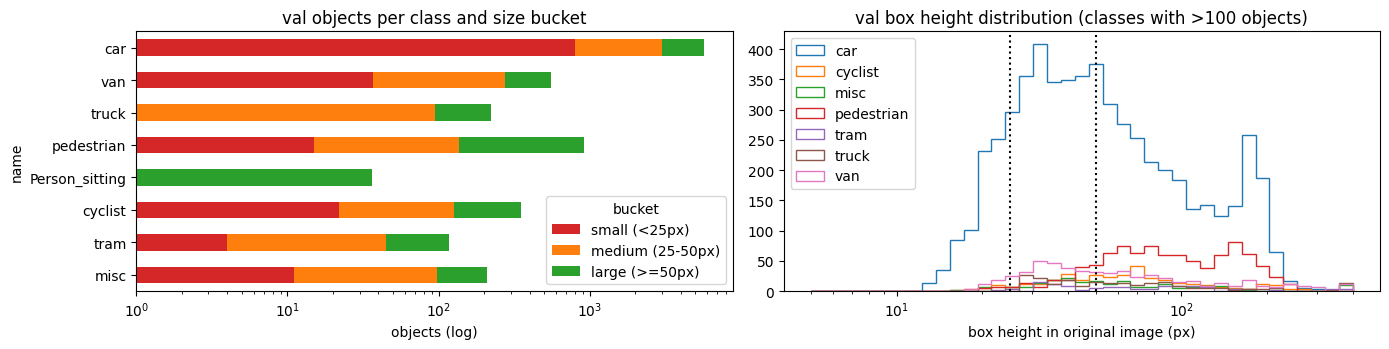

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(14, 3.6))
by_size.plot.barh(stacked=True, ax=ax[0], color=["#d62728", "#ff7f0e", "#2ca02c"])
ax[0].set_xscale("log"); ax[0].set_xlabel("objects (log)"); ax[0].set_title("val objects per class and size bucket")
ax[0].invert_yaxis()
for name, g in val.groupby("name"):
    if len(g) > 100:
        ax[1].hist(g.h_px, bins=np.logspace(np.log10(5), np.log10(400), 40), histtype="step", lw=1.5, label=name)
for b in (25, 50):
    ax[1].axvline(b, color="k", ls=":")
ax[1].set_xscale("log"); ax[1].set_xlabel("box height in original image (px)"); ax[1].legend()
ax[1].set_title("val box height distribution (classes with >100 objects)")
plt.tight_layout(); plt.show()

The small bucket is dominated by cars (800 of 889 val objects); small pedestrians (15), cyclists (22) and trams (4) are
too few for a stable AP. **Primary small-object metric: AP50-95 of `car` in the small bucket**; bucket mAP is reported
with that caveat.

## 3. Experiment configuration

Shared by runs A, B. The file on Drive is authoritative: if it exists and differs from the values below, the
cell stops. `optimizer` is set explicitly because `auto` silently switches between MuSGD and AdamW depending on the
iteration count and ignores `lr0`. `patience` > `epochs` disables early stopping. With `nbs=64` Ultralytics
accumulates gradients over 4 batches of 16, so `batch` mainly sets memory use.

In [7]:
EXP = dict(
    data=str(DATA_YAML), imgsz=640, epochs=50, batch=16, seed=0, deterministic=True,
    optimizer="SGD", lr0=0.01, lrf=0.01, momentum=0.937, weight_decay=0.0005,
    warmup_epochs=3.0, close_mosaic=10, amp=True, cache="ram", workers=2, patience=100,
    pretrained=True, plots=True, val=True,
)
cfg_path = ROOT / "exp_config.yaml"
if cfg_path.exists():
    diff = {k: (v, EXP[k]) for k, v in yaml.safe_load(cfg_path.read_text()).items() if EXP.get(k) != v}
    assert not diff, f"exp_config.yaml differs: {diff}"
else:
    cfg_path.write_text(yaml.safe_dump(EXP, sort_keys=False))
SMOKE_OVERRIDES = dict(epochs=2, fraction=0.1, data=str(RUN_DATA), cache=False) if SMOKE else {}
pd.DataFrame([{**EXP, **SMOKE_OVERRIDES}]).T.astype(str).rename(columns={0: "value"})

,value
data,/content/datasets/kitti.yaml
imgsz,640
epochs,50
batch,16
seed,0
deterministic,True
optimizer,SGD
lr0,0.01
lrf,0.01
momentum,0.937


## 4. Weight transfer from COCO

The trainer builds a fresh 8-class model and copies every COCO tensor whose name and shape match
(`intersect_dicts`), plus the class-bias rows of classes whose names exist in COCO (`cls_remap`: `car`, `truck`).
The class branch is almost entirely re-initialised because its width depends on the class count
(`c3 = max(ch[0], min(nc, 100))`: 80 channels for COCO, 64 for KITTI). Runs B and C inherit exactly the same
neck/head transfer.

In [8]:
from ultralytics.nn.tasks import DetectionModel
from ultralytics.utils.torch_utils import intersect_dicts

coco = YOLO("yolo26n.pt").model.float()
kitti = DetectionModel("yolo26n.yaml", nc=len(NAMES), verbose=False)
kitti.names = NAMES
copied = set(intersect_dicts(coco.state_dict(), kitti.state_dict()))
kitti.load(coco, verbose=True)                  # the call the trainer makes (prints Remapped / Transferred)

part = lambda k: "backbone (0-10)" if int(k.split(".")[1]) <= 10 else "neck (11-22)" if int(k.split(".")[1]) <= 22 else "head (23)"
t = pd.DataFrame([(part(k), k in copied, p.numel()) for k, p in kitti.named_parameters()], columns=["part", "pretrained", "params"])
t = t.pivot_table(index="part", columns="pretrained", values="params", aggfunc="sum", fill_value=0)
t.columns = ["re-initialised" if not c else "from COCO" for c in t.columns]
t = t.reindex(["backbone (0-10)", "neck (11-22)", "head (23)"])[["from COCO", "re-initialised"]]; t.loc["total"] = t.sum()
t["re-initialised %"] = 100 * t["re-initialised"] / t.sum(axis=1)
new_modules = sorted({".".join(k.split(".")[2:5]) for k, _ in kitti.named_parameters() if k not in copied})
print("re-initialised modules:", ", ".join(new_modules))
del coco, kitti
t

Overriding model.yaml nc=80 with nc=8
Remapped 2/8 cls head rows from pretrained weights by class name
Transferred 612/708 items from pretrained weights
re-initialised modules: cv3.0.0, cv3.0.1, cv3.0.2, cv3.1.0, cv3.1.1, cv3.1.2, cv3.2.0, cv3.2.1, cv3.2.2, one2one_cv3.0.0, one2one_cv3.0.1, one2one_cv3.0.2, one2one_cv3.1.0, one2one_cv3.1.1, one2one_cv3.1.2, one2one_cv3.2.0, one2one_cv3.2.1, one2one_cv3.2.2


,from COCO,re-initialised,re-initialised %
part,,,
backbone (0-10),1365472,0,0.000
neck (11-22),897152,0,0.000
head (23),153496,90800,37.168
total,2416120,90800,3.622


## 5. Training

Skipped if `runs/<run>/weights/last.pt` exists and is marked finished (`epoch == -1`); resumed if it exists but is
unfinished (Colab disconnect); otherwise trained from `yolo26n.pt`. A callback logs per-epoch training time, peak GPU
memory and the effective batch size to `epoch_log.csv` (Ultralytics can shrink the batch after a CUDA OOM).

In [9]:
RUNS = ROOT / "runs"
run_dir = RUNS / RUN_NAME
last_pt, best_pt, epoch_log = run_dir / "weights/last.pt", run_dir / "weights/best.pt", run_dir / "epoch_log.csv"

def add_logging_callbacks(model):
    state = {}
    def start(tr):
        state["t0"] = time.time()
        if torch.cuda.is_available():
            torch.cuda.reset_peak_memory_stats()
    def end(tr):
        cuda = torch.cuda.is_available()
        row = dict(epoch=tr.epoch + 1, train_seconds=time.time() - state["t0"], batch=tr.batch_size,
                   peak_alloc_mib=torch.cuda.max_memory_allocated() / 2**20 if cuda else 0.0,
                   peak_reserved_mib=torch.cuda.max_memory_reserved() / 2**20 if cuda else 0.0)
        pd.DataFrame([row]).to_csv(epoch_log, mode="a", header=not epoch_log.exists(), index=False)
    model.add_callback("on_train_epoch_start", start)
    model.add_callback("on_train_epoch_end", end)
    return model

finished = last_pt.exists() and torch.load(last_pt, map_location="cpu", weights_only=False).get("epoch", -1) == -1
if finished:
    print(f"finished run found, training skipped: {run_dir}")
elif last_pt.exists():
    add_logging_callbacks(YOLO(str(last_pt))).train(resume=True)
else:
    args = {**EXP, **SMOKE_OVERRIDES, "project": str(RUNS), "name": RUN_NAME, "exist_ok": True, "device": DEVICE}
    add_logging_callbacks(YOLO("yolo26n.pt")).train(**args)
assert best_pt.exists()

finished run found, training skipped: /content/drive/MyDrive/lab/runs/A_yolo26n


## 6. Training curves

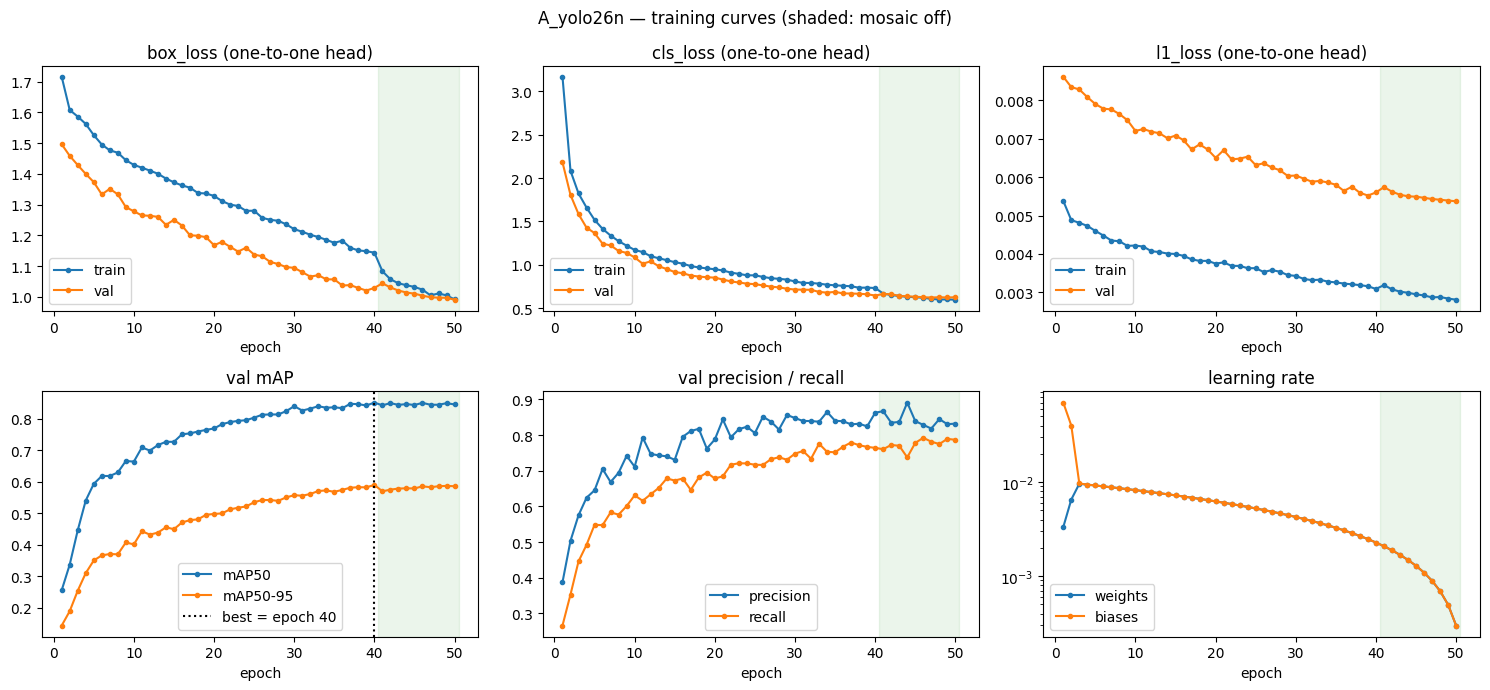

,value
epochs,50
best epoch,40
best mAP50-95,0.59
last mAP50-95,0.586
"mAP50-95 slope, last 5 epochs (/epoch)",0.0
val box_loss min epoch,50
train s/epoch (mean),103.836
peak train GPU mem allocated (MiB),2423.187
peak train GPU mem reserved (MiB),2632.0
batch (effective),16


In [10]:
res = pd.read_csv(run_dir / "results.csv"); res.columns = [c.strip() for c in res.columns]
elog = pd.read_csv(epoch_log).drop_duplicates("epoch", keep="last") if epoch_log.exists() else None
E = len(res); best_ep = int(res.loc[res["metrics/mAP50-95(B)"].idxmax(), "epoch"])
mosaic_off = {**EXP, **SMOKE_OVERRIDES}["epochs"] - EXP["close_mosaic"] + 0.5

fig, ax = plt.subplots(2, 3, figsize=(15, 7))
for j, name in enumerate(["box_loss", "cls_loss", "l1_loss"]):
    ax[0, j].plot(res.epoch, res[f"train/{name}"], ".-", label="train")
    ax[0, j].plot(res.epoch, res[f"val/{name}"], ".-", label="val")
    ax[0, j].set_title(f"{name} (one-to-one head)")
ax[1, 0].plot(res.epoch, res["metrics/mAP50(B)"], ".-", label="mAP50")
ax[1, 0].plot(res.epoch, res["metrics/mAP50-95(B)"], ".-", label="mAP50-95")
ax[1, 0].axvline(best_ep, color="k", ls=":", label=f"best = epoch {best_ep}"); ax[1, 0].set_title("val mAP")
ax[1, 1].plot(res.epoch, res["metrics/precision(B)"], ".-", label="precision")
ax[1, 1].plot(res.epoch, res["metrics/recall(B)"], ".-", label="recall"); ax[1, 1].set_title("val precision / recall")
ax[1, 2].plot(res.epoch, res["lr/pg0"], ".-", label="weights"); ax[1, 2].plot(res.epoch, res["lr/pg2"], ".-", label="biases")
ax[1, 2].set_yscale("log"); ax[1, 2].set_title("learning rate")
for a in ax.flat:
    a.axvspan(max(mosaic_off, 0.5), E + 0.5, color="green", alpha=.08); a.set_xlabel("epoch"); a.legend()
fig.suptitle(f"{RUN_NAME} — training curves (shaded: mosaic off)"); plt.tight_layout(); plt.show()

m = res["metrics/mAP50-95(B)"].values; vb = res["val/box_loss"].values
k = min(5, E - 1)
curve = pd.Series({
    "epochs": E, "best epoch": best_ep, "best mAP50-95": m.max(), "last mAP50-95": m[-1],
    f"mAP50-95 slope, last {k} epochs (/epoch)": np.polyfit(np.arange(k), m[-k:], 1)[0] if k >= 2 else np.nan,
    "val box_loss min epoch": int(res.epoch[vb.argmin()]),
    "train s/epoch (mean)": elog.train_seconds.mean() if elog is not None else np.nan,
    "peak train GPU mem allocated (MiB)": elog.peak_alloc_mib.max() if elog is not None else np.nan,
    "peak train GPU mem reserved (MiB)": elog.peak_reserved_mib.max() if elog is not None else np.nan,
    "batch (effective)": int(elog.batch.iloc[-1]) if elog is not None else np.nan,
}, dtype=object)
curve.to_frame("value")

**Colab T4 run:** mAP50-95 peaks at 0.590 (epoch 40) and is flat over the last five epochs (+0.0005/epoch); val
box loss keeps decreasing to the last epoch, so there is no overfitting and 50 epochs is sufficient. Train loss sits
above val loss until mosaic is switched off (epoch 41), when the two meet — the gap is augmentation, not
generalisation. Switching mosaic off did not improve val mAP here. Training: 104 s/epoch, 2.4 GiB peak allocated
memory, batch unchanged at 16.

## 7. Evaluation (best.pt)

Standard Ultralytics validation on the full val split (`conf=0.001`, NMS IoU 0.7, rectangular batches). These are
the headline numbers of the comparison table.

In [11]:
best = YOLO(str(best_pt))
val_dir = run_dir / "val_best"
metrics = best.val(data=str(RUN_DATA), imgsz=EXP["imgsz"], batch=EXP["batch"], device=DEVICE, plots=True,
                   project=str(run_dir), name="val_best", exist_ok=True, verbose=False)
n_gt = val.groupby("cls").size()
per_class = pd.DataFrame([dict(cls=NAMES[int(c)], n_gt=int(n_gt.get(int(c), 0)),
                               **dict(zip(["P", "R", "AP50", "AP50-95"], metrics.box.class_result(i))))
                          for i, c in enumerate(metrics.box.ap_class_index)]).set_index("cls")
overall = dict(mAP50=float(metrics.box.map50), mAP50_95=float(metrics.box.map), P=float(metrics.box.mp), R=float(metrics.box.mr))
per_class.loc["all"] = [len(val), overall["P"], overall["R"], overall["mAP50"], overall["mAP50_95"]]
per_class["n_gt"] = per_class["n_gt"].astype(int)
per_class.round(3)

Ultralytics 8.4.165 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 120 layers, 2,376,396 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1147.3±294.9 MB/s, size: 49.4 KB)
val: Scanning /content/datasets/kitti/labels/val... 1496 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1496/1496 1.9Kit/s 0.8s
val: New cache created: /content/datasets/kitti/labels/val.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 94/94 6.8it/s 13.8s
                   all       1496       8128      0.864      0.762      0.849      0.588
Speed: 0.5ms preprocess, 2.1ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to /content/drive/MyDrive/lab/runs/A_yolo26n/val_best


,n_gt,P,R,AP50,AP50-95
cls,,,,,
car,5716,0.925,0.893,0.955,0.752
van,555,0.902,0.836,0.914,0.692
truck,223,0.976,0.893,0.959,0.767
pedestrian,921,0.830,0.604,0.728,0.398
Person_sitting,36,0.646,0.611,0.674,0.349
cyclist,352,0.843,0.685,0.781,0.473
tram,117,0.888,0.884,0.937,0.690
misc,208,0.900,0.690,0.841,0.583
all,8128,0.864,0.762,0.849,0.588


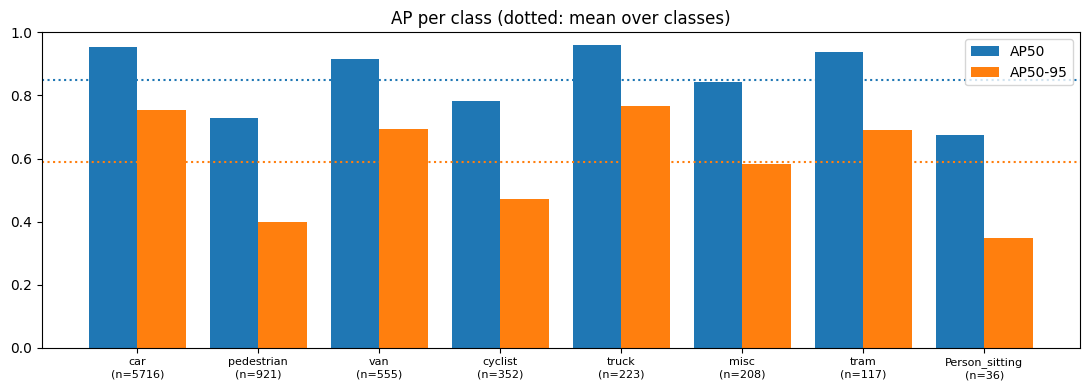

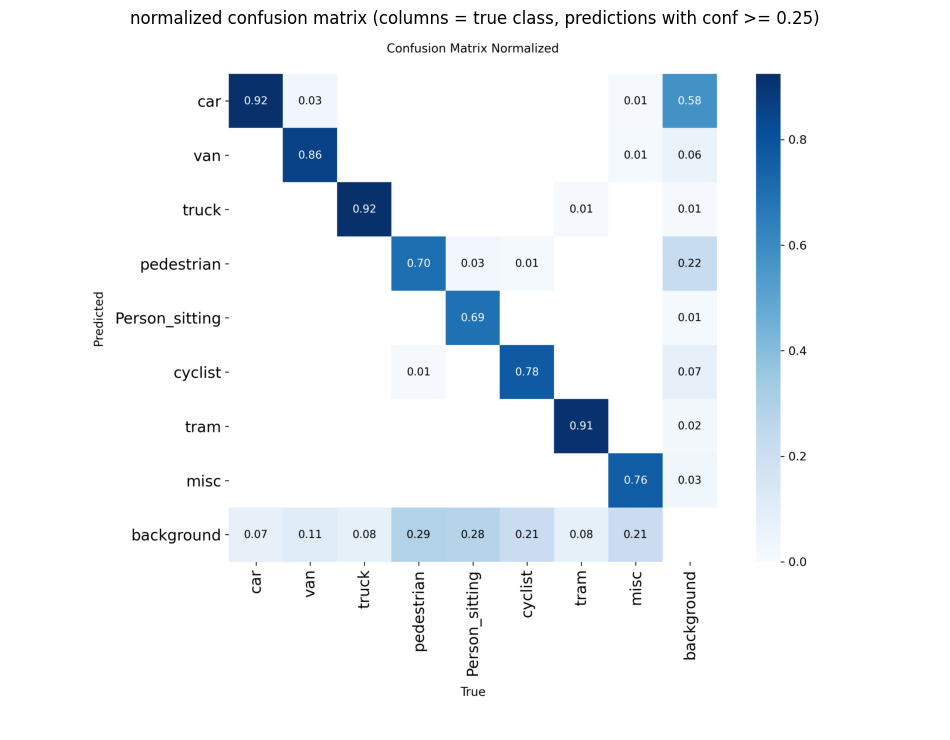

In [12]:
pc = per_class.drop("all").sort_values("n_gt", ascending=False)
fig, ax = plt.subplots(figsize=(11, 4)); ax = [ax]
x = np.arange(len(pc))
ax[0].bar(x - .2, pc.AP50, .4, label="AP50"); ax[0].bar(x + .2, pc["AP50-95"], .4, label="AP50-95")
ax[0].axhline(overall["mAP50"], color="C0", ls=":"); ax[0].axhline(overall["mAP50_95"], color="C1", ls=":")
ax[0].set_xticks(x, [f"{c}\n(n={n})" for c, n in zip(pc.index, pc.n_gt)], fontsize=8); ax[0].set_ylim(0, 1)
ax[0].legend(); ax[0].set_title("AP per class (dotted: mean over classes)")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(10, 7.5))
ax.imshow(plt.imread(val_dir / "confusion_matrix_normalized.png")); ax.axis("off")
ax.set_title("normalized confusion matrix (columns = true class, predictions with conf >= 0.25)")
plt.tight_layout(); plt.show()

**Colab T4 run:** mAP50-95 0.588, mAP50 0.849. Vehicles score 0.69–0.77 AP50-95; the person classes are the weak
point (cyclist 0.47, pedestrian 0.40, Person_sitting 0.35 on only 36 objects). Pedestrians have a large AP50 → AP50-95
drop (0.73 → 0.40), i.e. they are found but localised poorly. The confusion matrix shows almost no inter-class
confusion (largest: van→car 3 %); errors are misses (background row: pedestrian 29 %, Person_sitting 28 %,
cyclist 21 %) and false positives, mostly labelled `car` (58 % of background detections).

## 8. AP by object size

`lab_eval.bucket_ap` computes COCO-style AP restricted to one height bucket: a detection matched to a ground-truth box
outside the bucket, or an unmatched detection whose own height is outside the bucket, is ignored. Predictions come
from batch-1 inference with the same thresholds as `val()`. The first cell checks the implementation against
Ultralytics on synthetic data (all-size bucket must be identical).

In [13]:
from ultralytics.models.yolo.detect import DetectionValidator
from ultralytics.utils.metrics import ap_per_class, box_iou

rng, v = np.random.default_rng(0), DetectionValidator()
v.iouv = torch.linspace(0.5, 0.95, 10)
recs, T, C, P, G = [], [], [], [], []
for _ in range(300):
    L = rng.integers(0, 8); gc = rng.integers(0, 4, L); xy = rng.uniform(0, 1000, (L, 2))
    gb = np.concatenate([xy, xy + rng.uniform(8, 120, (L, 2))], 1).astype(np.float32)
    keep = rng.random(L) < 0.8; pb = gb[keep] + rng.normal(0, 4, (keep.sum(), 4)).astype(np.float32); pc_ = gc[keep].copy()
    R = rng.integers(0, 5); xy2 = rng.uniform(0, 1000, (R, 2))
    pb = np.concatenate([pb, np.concatenate([xy2, xy2 + rng.uniform(8, 80, (R, 2))], 1).astype(np.float32)])
    pc_ = np.concatenate([pc_, rng.integers(0, 4, R)]); cf = rng.random(len(pb)).astype(np.float32)
    recs.append(make_record(pb, pc_, cf, gc, gb))
    iou = box_iou(torch.tensor(gb), torch.tensor(pb)) if L and len(pb) else torch.zeros(L, len(pb))
    T.append(v.match_predictions(torch.tensor(pc_), torch.tensor(gc), iou).numpy()); C.append(cf); P.append(pc_); G.append(gc)
ref = ap_per_class(np.concatenate(T), np.concatenate(C), np.concatenate(P), np.concatenate(G))[5]
assert np.array_equal(ref, bucket_ap(recs, 4)["ap"])
print("evaluator check passed: all-size AP identical to Ultralytics")

evaluator check passed: all-size AP identical to Ultralytics


In [15]:
t0 = time.time()

recs_A = collect_predictions(best, val, imgsz=EXP["imgsz"], device=DEVICE)
size_df = size_table(recs_A, NAMES)
size_df.insert(1, "car n_gt", [len(val[val.name == "car"])] + [int(by_size.loc["car", b]) for b in SIZE_BUCKETS])
print(f"{len(recs_A)} images in {time.time() - t0:.0f} s | all-size bucket vs val(): "
      f"mAP50-95 {size_df.loc['all', 'mAP50-95']:.4f} vs {overall['mAP50_95']:.4f} (batch-1 vs rect-batch padding)")
size_df[["n_gt", "mAP50", "mAP50-95", "car n_gt", "car", "van", "pedestrian", "cyclist"]].round(3)

1496 images in 27 s | all-size bucket vs val(): mAP50-95 0.5840 vs 0.5880 (batch-1 vs rect-batch padding)


,n_gt,mAP50,mAP50-95,car n_gt,car,van,pedestrian,cyclist
bucket,,,,,,,,
all,8128,0.842,0.584,5716,0.750,0.685,0.398,0.481
small (<25px),889,0.530,0.306,800,0.550,0.371,0.024,0.195
medium (25-50px),2903,0.695,0.455,2214,0.706,0.591,0.119,0.390
large (>=50px),4336,0.881,0.646,2702,0.832,0.794,0.446,0.550


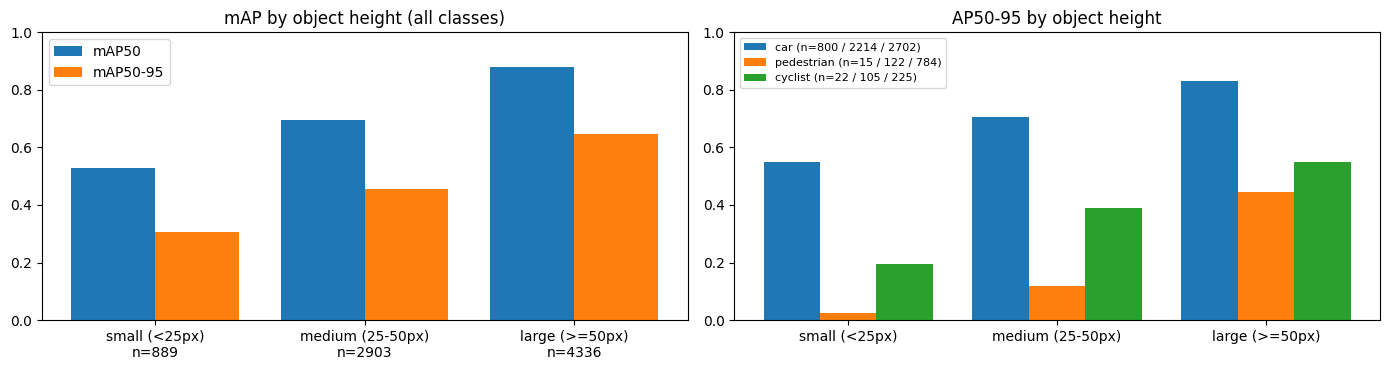

In [16]:
sd = size_df.drop("all"); x = np.arange(len(sd))
fig, ax = plt.subplots(1, 2, figsize=(14, 3.8))
ax[0].bar(x - .2, sd.mAP50, .4, label="mAP50"); ax[0].bar(x + .2, sd["mAP50-95"], .4, label="mAP50-95")
ax[0].set_xticks(x, [f"{b}\nn={n}" for b, n in zip(sd.index, sd.n_gt)]); ax[0].set_ylim(0, 1); ax[0].legend()
ax[0].set_title("mAP by object height (all classes)")
for j, c in enumerate(["car", "pedestrian", "cyclist"]):
    ax[1].bar(x + (j - 1) * .27, sd[c], .27, label=f"{c} (n={' / '.join(str(int(by_size.loc[c, b])) for b in SIZE_BUCKETS)})")
ax[1].set_xticks(x, sd.index); ax[1].set_ylim(0, 1); ax[1].legend(fontsize=8); ax[1].set_title("AP50-95 by object height")
plt.tight_layout(); plt.show()

**Colab T4 run:** mAP50-95 0.306 / 0.455 / 0.646 for small / medium / large. Primary small-object metric, car AP50-95
in the small bucket: **0.550** (800 objects) vs 0.832 for large cars. Pedestrians are weak at every size (0.45 even
when large), so their low AP is not only a size effect; the small pedestrian (15 objects) and cyclist (22) values are
not reliable.

## 9. Feature maps

PCA-RGB of the three backbone outputs handed to the neck (layers 4, 6, 10 → P3, P4, P5; these are the tensors the
ZipDepth encoder replaces in Run B) and of the three neck outputs fed to the detection head (layers 16, 19, 22).
Each map is projected onto its top-3 principal components (colour = PC1–3, 1–99 % percentile scaling); the title
gives shape and the variance explained by the three components. Input: the val image with the most small objects,
resized to 192×640.

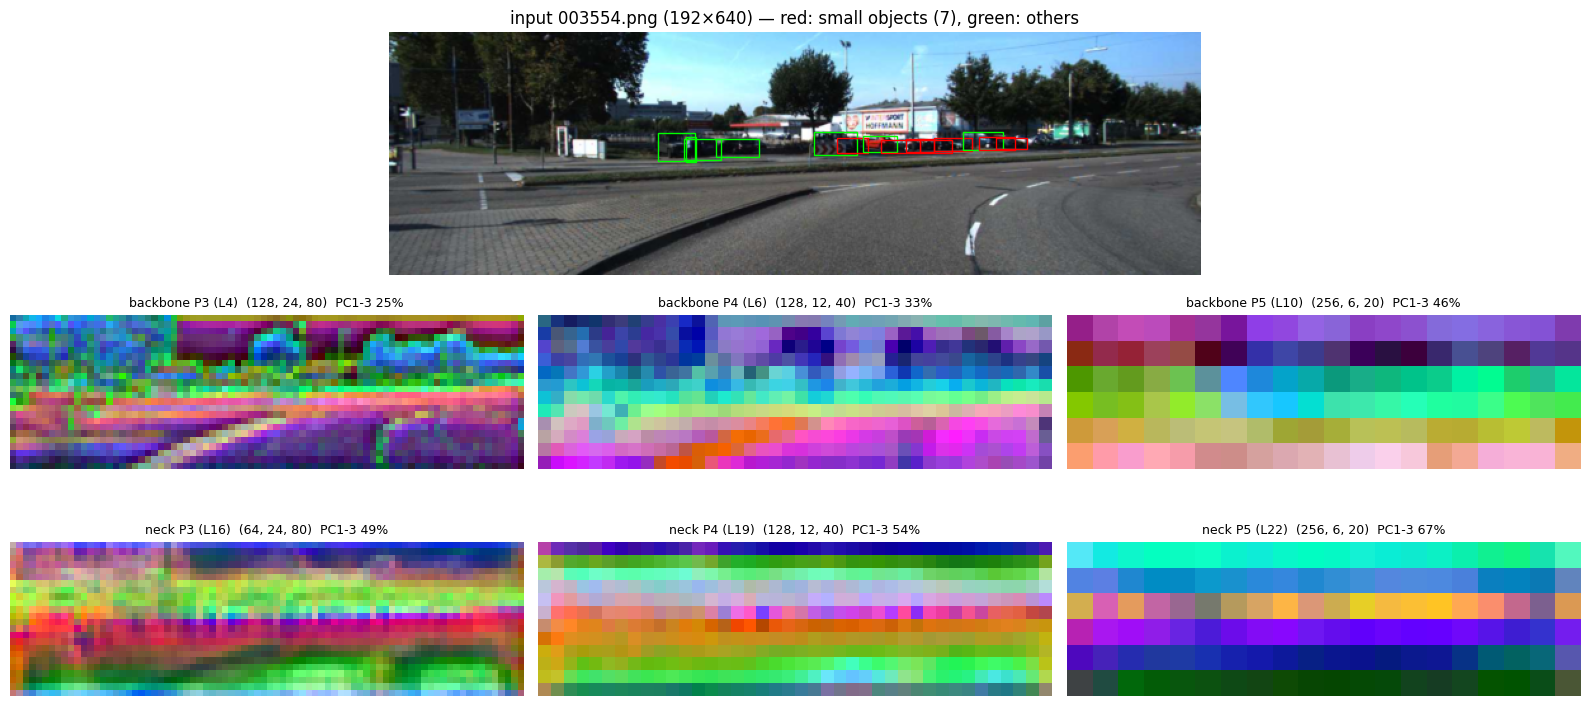

In [17]:
LAYERS = {"backbone P3 (L4)": 4, "backbone P4 (L6)": 6, "backbone P5 (L10)": 10,
          "neck P3 (L16)": 16, "neck P4 (L19)": 19, "neck P5 (L22)": 22}
n_small = val[val.bucket == list(SIZE_BUCKETS)[0]].groupby("path").size().sort_values(ascending=False)
feat_img = n_small.index[0]
rgb = np.array(Image.open(feat_img).convert("RGB").resize((640, 192), Image.BILINEAR))
x = torch.from_numpy(rgb).permute(2, 0, 1)[None].float().div(255).to(DEVICE)

net = copy.deepcopy(best.model).float().eval().to(DEVICE)
feats = {}
hooks = [net.model[i].register_forward_hook(lambda m, inp, out, k=k: feats.__setitem__(k, out[0].detach().float().cpu()))
         for k, i in LAYERS.items()]
with torch.no_grad():
    net(x)
for h in hooks:
    h.remove()

fig = plt.figure(figsize=(16, 7.5)); gs = fig.add_gridspec(3, 3, height_ratios=[1.1, 1, 1])
a = fig.add_subplot(gs[0, :]); a.imshow(rgb); a.axis("off")
g = val[val.path == feat_img]
for _, r in g.iterrows():
    s = 640 / r.img_w
    a.add_patch(plt.Rectangle((r.x1 * s, r.y1 * 192 / r.img_h), (r.x2 - r.x1) * s, (r.y2 - r.y1) * 192 / r.img_h,
                              fill=False, ec="lime" if r.bucket != list(SIZE_BUCKETS)[0] else "red", lw=1))
a.set_title(f"input {Path(feat_img).name} (192×640) — red: small objects ({int(n_small.iloc[0])}), green: others")
pca_var = {}
for n, (k, f) in enumerate(feats.items()):
    img, var = pca_rgb(f); pca_var[k] = var
    ax = fig.add_subplot(gs[1 + n // 3, n % 3]); ax.imshow(img, interpolation="nearest"); ax.axis("off")
    ax.set_title(f"{k}  {tuple(f.shape)}  PC1-3 {100 * var:.0f}%", fontsize=9)
plt.tight_layout(); plt.show()

## 10. Model cost

Parameters before and after fusion (`fuse()` merges BatchNorm into convolutions and drops the unused one-to-one head,
so the fused count is the deployed model), GFLOPs at 640×640, and GPU latency of the fused network only (no
pre-processing, no NMS): batch 1 at 640×640 and at 224×640 (a letterboxed KITTI frame), FP32 and FP16, 30 warm-up +
200 timed runs. Throughput is measured at batch 32 (FP16) because batch-1 latency of a model this small is dominated
by kernel-launch overhead rather than compute. Final A/B/C timings should be taken back-to-back in one session.

In [18]:
from ultralytics.utils.torch_utils import get_flops

def split_params(dm):
    out = {"backbone (0-10)": 0, "neck (11-22)": 0, "head (23)": 0}
    for i, layer in enumerate(dm.model):
        out["backbone (0-10)" if i <= 10 else "neck (11-22)" if i <= 22 else "head (23)"] += count_params(layer)
    return out

net = copy.deepcopy(best.model).float().eval()
net_fused = copy.deepcopy(net).fuse(verbose=False)
params = pd.DataFrame({"unfused": split_params(net), "fused": split_params(net_fused)}); params.loc["total"] = params.sum()
gflops = get_flops(net_fused, EXP["imgsz"])

gpu = DEVICE != "cpu"
lat = []
for shape in [(1, 3, 640, 640), (1, 3, 224, 640)]:
    for half in ([False, True] if gpu else [False]):
        L = measure_latency(net_fused, shape, DEVICE, half=half, warmup=30 if gpu else 3, iters=200 if gpu else 10)
        M = peak_inference_memory(net_fused, shape, DEVICE, half=half)
        lat.append(dict(batch=1, input=f"{shape[2]}x{shape[3]}", precision="FP16" if half else "FP32",
                        median_ms=L["median"], p90_ms=L["p90"], img_per_s=1000 / L["median"],
                        peak_mem_mib=M["total_mib"], activ_mem_mib=M["activations_mib"]))
tb = 32 if gpu else 4
L = measure_latency(net_fused, (tb, 3, 640, 640), DEVICE, half=gpu, warmup=10 if gpu else 1, iters=50 if gpu else 3)
M = peak_inference_memory(net_fused, (tb, 3, 640, 640), DEVICE, half=gpu)
lat.append(dict(batch=tb, input="640x640", precision="FP16" if gpu else "FP32", median_ms=L["median"], p90_ms=L["p90"],
                img_per_s=tb * 1000 / L["median"], peak_mem_mib=M["total_mib"], activ_mem_mib=M["activations_mib"]))
lat_df = pd.DataFrame(lat)
print(f"GFLOPs @640 (fused): {gflops:.2f} | device: {GPU_NAME}")
display(params.map(lambda v: f"{v:,}"))
lat_df.round(2)

GFLOPs @640 (fused): 5.32 | device: Tesla T4


,unfused,fused
backbone (0-10),"1,365,472","1,361,288"
neck (11-22),"897,152","894,080"
head (23),"244,296","121,028"
total,"2,506,920","2,376,396"


,batch,input,precision,median_ms,p90_ms,img_per_s,peak_mem_mib,activ_mem_mib
0,1,640x640,FP32,9.07,13.82,110.27,84.68,19.14
1,1,640x640,FP16,9.94,10.51,100.58,68.01,9.38
2,1,224x640,FP32,8.93,9.69,112.02,71.75,9.33
3,1,224x640,FP16,13.37,17.32,74.80,60.36,3.29
4,32,640x640,FP16,62.40,62.98,512.83,432.29,300.01


**Colab T4 run (batch 1):** ~10 ms at both 640×640 and 224×640 and no gain from FP16 — at batch 1 the T4 is idle
most of the time (launch-bound), so these numbers mostly reflect layer count, not FLOPs. The batch-32 throughput row
is the compute-bound comparison point for Run B.

## 11. Qualitative results

Two val images with the most small objects and two random ones (fixed list saved to `results/qualitative_images.txt`
and reused for runs B and C). Top: ground truth (red = small); bottom: predictions with confidence ≥ 0.25.

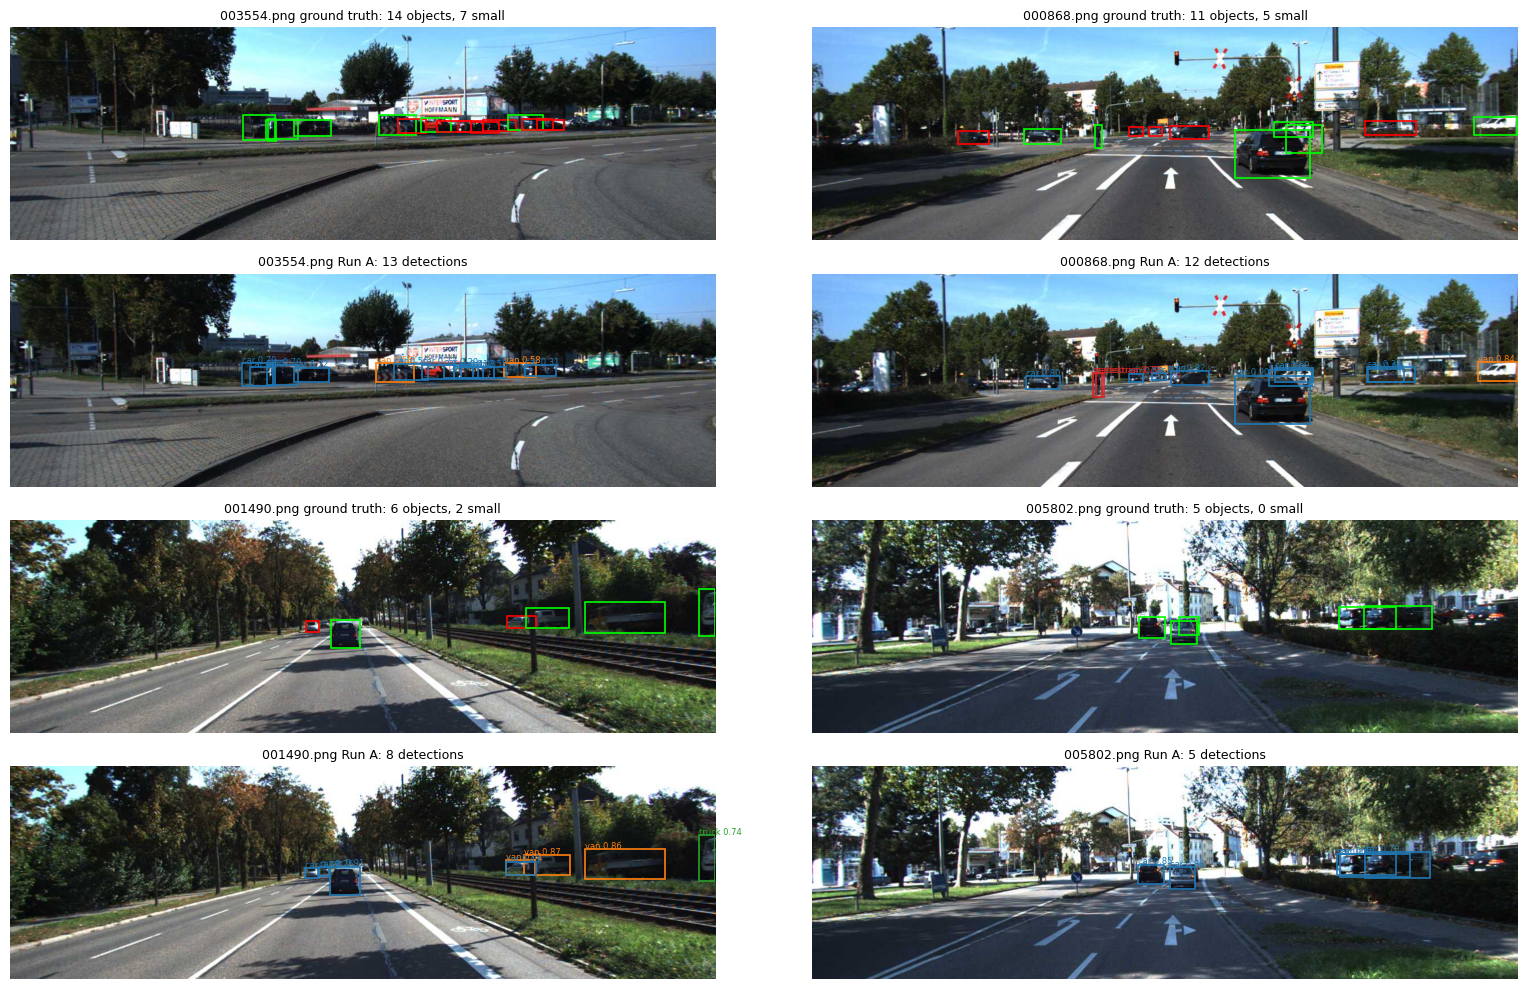

In [19]:
qfile = ROOT / "results" / ("qualitative_images_smoke.txt" if SMOKE else "qualitative_images.txt")
if qfile.exists():
    SHOW = [str(KITTI_DIR / "images/val" / n) for n in qfile.read_text().split()]
    SHOW = [p for p in SHOW if p in set(val.path)] or None
else:
    SHOW = None
if not SHOW:
    SHOW = list(n_small.index[:2]) + random.Random(1).sample([p for p in val.path.unique() if p not in n_small.index[:2]], 2)
    qfile.parent.mkdir(exist_ok=True); qfile.write_text("\n".join(Path(p).name for p in SHOW))

colors = plt.cm.tab10(np.arange(len(NAMES)))
fig, axes = plt.subplots(4, 2, figsize=(16, 10))
for j, p in enumerate(SHOW):
    img = np.asarray(Image.open(p).convert("RGB")); g = val[val.path == p]
    r = best.predict(p, imgsz=EXP["imgsz"], conf=0.25, device=DEVICE, verbose=False)[0]
    a_gt, a_pr = axes[(j // 2) * 2, j % 2], axes[(j // 2) * 2 + 1, j % 2]
    for a in (a_gt, a_pr):
        a.imshow(img); a.axis("off")
    for _, b in g.iterrows():
        a_gt.add_patch(plt.Rectangle((b.x1, b.y1), b.x2 - b.x1, b.y2 - b.y1, fill=False, lw=1.2,
                                     ec="red" if b.bucket == list(SIZE_BUCKETS)[0] else "lime"))
    for c, s, (x1, y1, x2, y2) in zip(r.boxes.cls.int().tolist(), r.boxes.conf.tolist(), r.boxes.xyxy.tolist()):
        a_pr.add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, ec=colors[c], lw=1.2))
        a_pr.text(x1, y1 - 2, f"{NAMES[c]} {s:.2f}", color=colors[c], fontsize=6)
    a_gt.set_title(f"{Path(p).name} ground truth: {len(g)} objects, {(g.bucket == list(SIZE_BUCKETS)[0]).sum()} small", fontsize=9)
    a_pr.set_title(f"{Path(p).name} Run A: {len(r.boxes)} detections", fontsize=9)
plt.tight_layout(); plt.show()

## 12. Results export

All numbers are written to `results/results_A.json`; the comparison notebook reads the A, B and C files.

In [20]:
results_A = dict(
    run="A", name=RUN_NAME, smoke=SMOKE, backbone="YOLO26n (COCO-pretrained)", gpu=GPU_NAME,
    torch=torch.__version__, ultralytics=ultralytics.__version__, config={**EXP, **SMOKE_OVERRIDES},
    training={k: (v.item() if hasattr(v, "item") else v) for k, v in curve.items()},
    overall=overall, per_class=per_class.reset_index().to_dict("records"),
    by_size=size_df.reset_index().to_dict("records"),
    car_small_ap50_95=float(size_df.loc[list(SIZE_BUCKETS)[0], "car"]),
    params=dict(unfused=int(params.loc["total", "unfused"]), fused=int(params.loc["total", "fused"]),
                by_part=params.drop("total").to_dict()),
    gflops_640=float(gflops), latency=lat_df.to_dict("records"), pca_var_top3=pca_var,
    val_speed_ms=metrics.speed,
)
out = ROOT / "results" / ("results_A_smoke.json" if SMOKE else "results_A.json")
save_json(results_A, out)

b1 = lat_df[(lat_df.batch == 1) & (lat_df.input == "640x640")].iloc[-1]; bt = lat_df.iloc[-1]
pd.Series({
    "mAP50": overall["mAP50"], "mAP50-95": overall["mAP50_95"],
    "AP50-95 car / pedestrian / cyclist": " / ".join(f"{per_class.loc[c, 'AP50-95']:.3f}" for c in ["car", "pedestrian", "cyclist"]),
    "mAP50-95 small / medium / large": " / ".join(f"{size_df.loc[b, 'mAP50-95']:.3f}" for b in SIZE_BUCKETS),
    "AP50-95 car small (primary)": results_A["car_small_ap50_95"],
    "params fused": f"{results_A['params']['fused']:,}", "GFLOPs @640": gflops,
    f"latency b1 640 {b1.precision} (ms)": b1.median_ms, f"throughput b{int(bt.batch)} {bt.precision} (img/s)": bt.img_per_s,
    "peak train GPU mem (MiB)": curve["peak train GPU mem allocated (MiB)"], "saved to": str(out),
}, name=f"Run A{' (SMOKE)' if SMOKE else ''}").to_frame()

,Run A
mAP50,0.849
mAP50-95,0.588
AP50-95 car / pedestrian / cyclist,0.752 / 0.398 / 0.473
mAP50-95 small / medium / large,0.306 / 0.455 / 0.646
AP50-95 car small (primary),0.55
params fused,"2,376,396"
GFLOPs @640,5.317
latency b1 640 FP16 (ms),9.942
throughput b32 FP16 (img/s),512.826
peak train GPU mem (MiB),2423.187
